## Elo Rating Tuning method

This code helps with the tuning of the K value of the Elo method.  

We also produce the probalitity mean square error via: 

http://opisthokonta.net/?p=1387

Reference: https://www.gautamnarula.com/rating/

***

### Elo method but not square error is integrated into the code. 

In [6]:
import math 
  
# Function to calculate the Probability 
def Probability(rating1, rating2): 
  
    return 1.0 * 1.0 / (1 + 1.0 * math.pow(10, 1.0 * (rating1 - rating2) / 400)) 
  
# Function to calculate Elo rating 
# K is a constant. 
# Player A wins over Player B.  
# tie = true if tie, false otherwise
def EloRating(Ra, Rb, K, tie, see): 
    
    # To calculate the Winning 
    # Probability of Player B 
    Pb = Probability(Ra, Rb) 
  
    # To calculate the Winning 
    # Probability of Player A 
    Pa = Probability(Rb, Ra) 
  
    # Updating the Elo Ratings 
    if tie:
       Ra = Ra + K * (1/2 - Pa) 
       Rb = Rb + K * (1/2 - Pb) 
       see=se+(Pa-1/2)**2+(Pb-1/2)**2
    else:        
       Ra = Ra + K * (1 - Pa) 
       Rb = Rb + K * (0 - Pb) 
       see=se+(Pa-1)**2+(Pb-0)**2
    
    return Ra, Rb, see

In [15]:
gameFilename = '24games.txt'
teamFilename = '24teams.txt'

### Load the team names into an array

In [18]:
import pandas as pd

teamNames = pd.read_csv(teamFilename, header = None)
numTeams = len(teamNames)

### Load the games

In [21]:
# columns of games are:
#	column 0 = days since 1/1/0000
#	column 1 = date in YYYYMMDD format
#	column 2 = team1 index
#	column 3 = team1 homefield (1 = home, -1 = away, 0 = neutral)
#	column 4 = team1 score
#	column 5 = team2 index
#	column 6 = team2 homefield (1 = home, -1 = away, 0 = neutral)
#	column 7 = team2 score
games = pd.read_csv(gameFilename, header = None)
numGames = len(games)

### Create Elo ratings

In [24]:
import numpy as np

eloRatings = np.zeros(numTeams)

numberTeamsToPrint = 20
se=0
for i in range(numGames):
    team1ID = games.loc[i, 2] - 1 # subtracting 1 since python indexes at 0
    team1Score = games.loc[i, 4]
    team2ID = games.loc[i, 5] - 1 # subtracting 1 since python indexes at 0
    team2Score = games.loc[i, 7]

    if team1Score > team2Score:
        team1Rating, team2Rating, se = EloRating(eloRatings[team1ID], eloRatings[team2ID], 32, False, se)
    elif team1Score < team2Score:
        team2Rating, team1Rating, se = EloRating(eloRatings[team2ID], eloRatings[team1ID], 32, False, se)
    else:  
        team1Rating, team2Rating, se = EloRating(eloRatings[team1ID], eloRatings[team2ID], 32, True, se)
        
    eloRatings[team1ID] = team1Rating
    eloRatings[team2ID] = team2Rating

### Sort and print the ranking of teams

In [27]:
iSort = np.argsort(-eloRatings)

print('\n\n************** ELO Rating Method **************\n')
print('===========================')
print('Rank   Rating      Team   ')
print('===========================')
for i in range(numberTeamsToPrint):
    print(f'{i+1:4d}   {eloRatings[iSort[i]]:.5f}  {teamNames.loc[iSort[i],1]}')

print('')   # extra carriage return



************** ELO Rating Method **************

Rank   Rating      Team   
   1   452.94229   3
   2   438.56075   10
   3   432.32762   9
   4   422.59216   11
   5   421.76058   6
   6   420.42524   15
   7   393.46984   14
   8   389.92796   5
   9   389.63976   2
  10   312.04719   8
  11   292.20781   13
  12   275.15968   12
  13   173.09552   7
  14   29.38611   Сахипов Амир
  15   18.46954   Юркевич Мирон
  16   17.82092   Шарел Марғұлан
  17   17.36184   Даутов Жан
  18   11.03746   Аманжолов Амирлан
  19   10.57486   Мурат Тимур
  20   6.32706   4



***

### This tunes K and is new. 

Best K is 136.000000


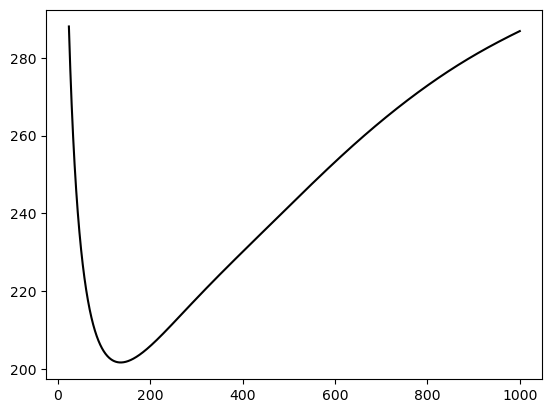

In [34]:
import matplotlib.pyplot as plt

# Set the parameters for looping through K
kStart = 24
kEnd = 1000
kStepSize = .2
kRange = np.arange(kStart,kEnd+kStepSize,kStepSize)

# Set up parameters to find the best K
bestK = kEnd*2
bestMSE = 4*numGames

mseList = []
for K in kRange: 
    se=0
    eloRatings = 1200*np.ones(numTeams)
    for i in range(numGames):
        team1ID = games.loc[i, 2] - 1 # subtracting 1 since python indexes at 0
        team1Score = games.loc[i, 4]
        team2ID = games.loc[i, 5] - 1 # subtracting 1 since python indexes at 0
        team2Score = games.loc[i, 7]

        if team1Score > team2Score:
            team1Rating, team2Rating, se = EloRating(eloRatings[team1ID], eloRatings[team2ID], K, False, se)
        elif team1Score < team2Score:
            team2Rating, team1Rating, se = EloRating(eloRatings[team2ID], eloRatings[team1ID], K, False, se)
        else:  
            team1Rating, team2Rating, se = EloRating(eloRatings[team1ID], eloRatings[team2ID], K, True, se)
        
        eloRatings[team1ID] = team1Rating
        eloRatings[team2ID] = team2Rating
        
 

    mseList.append(se) 
    

    if se < bestMSE:  
        bestMSE = se
        bestK = K

plt.plot(kRange,mseList,'k-')    
print('Best K is %f' % (bestK) )        